# Task 4: Predicting Insurance Claim Amounts

**Objective:** Estimate medical insurance charges using personal data.

**Dataset:** Medical Cost Personal Dataset (insurance.csv)

**Model:** Linear Regression

**Evaluation:** MAE and RMSE

In [2]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.0 MB 1.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.0 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.0 MB 1.6 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.0 MB 1.6 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.0 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.0 MB 1.8 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.0 MB 1.8 MB/s eta 0:00:03
   ----------------- ---------------------- 3.4/8.0 MB 1.7 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.0 MB 1.7 MB/s eta 0:00:03
   -------------------- ---------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Standard libraries for data work
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [15]:
# Read the CSV file into a DataFrame
# Make sure insurance.csv is in the same folder as this notebook
df = pd.read_csv('insurance.csv')

# Shape tells us rows × columns at a glance
print(f"Dataset shape: {df.shape}")

# head() shows the first 5 rows — quick sanity check
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# info() shows data types and non-null counts — tells us if anything is missing
print("=== Column info ===")
df.info()

# describe() gives mean, min, max etc. for numeric columns
print("\n=== Statistical summary ===")
df.describe()

=== Column info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

=== Statistical summary ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# isnull().sum() counts missing values in each column
# This is a required step — always show you checked, even if result is 0
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


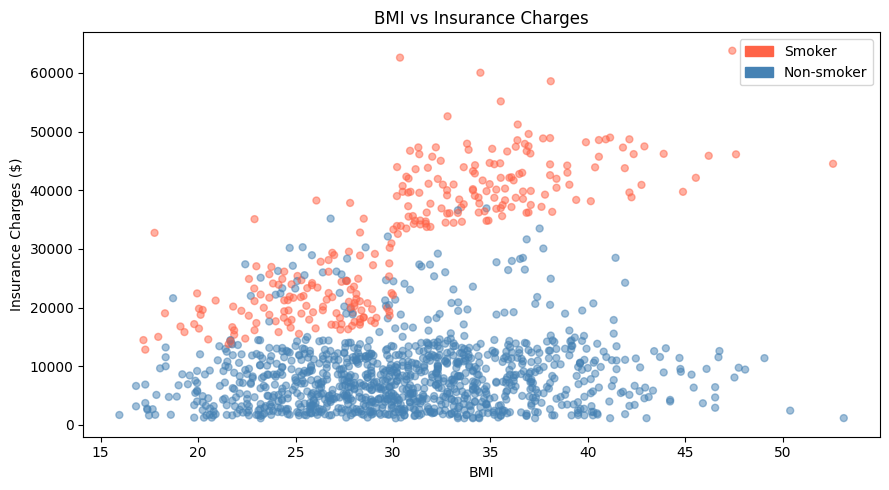

In [7]:
# Scatter plot: does higher BMI mean higher charges?
# We colour points by smoker status to reveal a hidden pattern
plt.figure(figsize=(9, 5))
colors = df['smoker'].map({'yes': 'tomato', 'no': 'steelblue'})
plt.scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=25)

# Labels and legend
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.title('BMI vs Insurance Charges')
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='tomato', label='Smoker'),
                    Patch(color='steelblue', label='Non-smoker')])
plt.tight_layout()
plt.show()

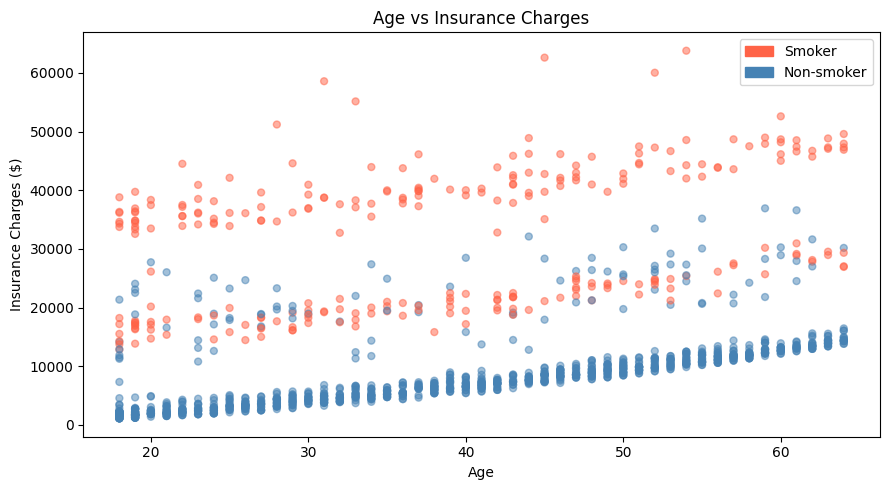

In [8]:
# Scatter plot: does age affect charges?
plt.figure(figsize=(9, 5))
plt.scatter(df['age'], df['charges'], c=colors, alpha=0.5, s=25)
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.title('Age vs Insurance Charges')
plt.legend(handles=[Patch(color='tomato', label='Smoker'),
                    Patch(color='steelblue', label='Non-smoker')])
plt.tight_layout()
plt.show()


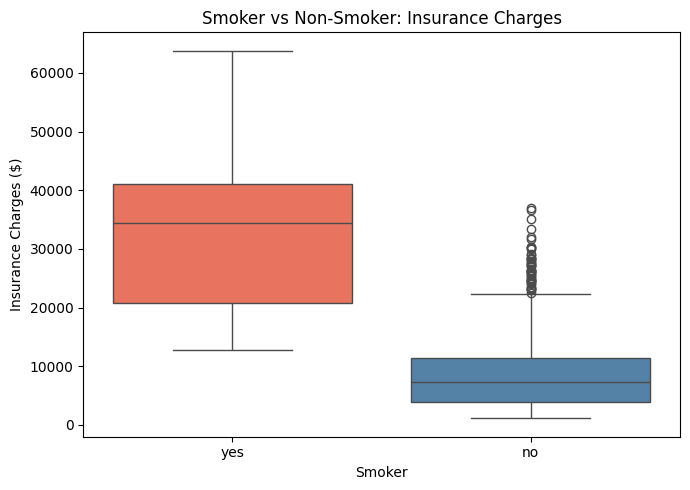

In [9]:
# Box plot: how much more do smokers pay than non-smokers?
# Box plots show median, spread, and outliers — perfect for comparing two groups
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='smoker', y='charges',
            palette={'yes': 'tomato', 'no': 'steelblue'})
plt.xlabel('Smoker')
plt.ylabel('Insurance Charges ($)')
plt.title('Smoker vs Non-Smoker: Insurance Charges')
plt.tight_layout()
plt.show()

In [10]:
# Models can't read text — we convert categorical columns to numbers
le = LabelEncoder()

df_model = df.copy()  # work on a copy so original df stays intact

# sex: male → 1, female → 0
df_model['sex'] = le.fit_transform(df_model['sex'])

# smoker: yes → 1, no → 0  (this will be our strongest predictor)
df_model['smoker'] = le.fit_transform(df_model['smoker'])

# region has 4 values — one-hot encoding creates separate 0/1 columns
# drop_first=True avoids multicollinearity (a regression issue)
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

print("Columns after encoding:")
print(df_model.columns.tolist())

Columns after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


In [11]:
# X = all features (inputs), y = what we want to predict (output)
X = df_model.drop('charges', axis=1)
y = df_model['charges']

# Split: 80% for training the model, 20% for testing it
# random_state=42 makes the split reproducible — same result every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 1070
Testing  samples : 268


In [12]:
# Create and train the Linear Regression model
# .fit() finds the best line through all training data points
model = LinearRegression()
model.fit(X_train, y_train)

print(" Model trained!")
print(f"Intercept: {model.intercept_:,.2f}")

 Model trained!
Intercept: -11,931.22


MAE  : $4,181.19
RMSE : $5,796.28
R²   : 0.7836


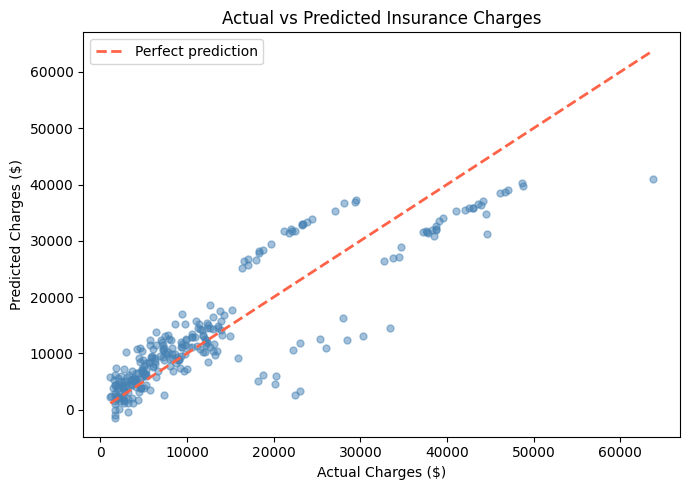

In [13]:
# Predict on test data — data the model has never seen
y_pred = model.predict(X_test)

# MAE: average dollar amount our prediction is off by
mae = mean_absolute_error(y_test, y_pred)

# RMSE: similar to MAE but penalises big mistakes more heavily
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² score: 1.0 = perfect, 0.0 = no better than guessing the mean
r2 = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

# Plot: how close are predictions to real values?
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=25)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='tomato', lw=2, linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()
# Points close to the red line = accurate predictions

## Conclusion

### Key Insights

- **Smoking is the #1 predictor** — smokers pay approximately 4× more in charges than non-smokers.
- **Age has a clear positive effect** — charges increase steadily as age rises.
- **BMI matters most for smokers** — high BMI combined with smoking leads to the highest charges.
- **Children and region have minimal impact** on charges.

### Model Performance

|Metric | Value |

   MAE  | $4,181.19
   
   RMSE | $5,796.28
   
   R²   | 0.7836

 ### Future Improvements

This model can be improved further by using more advanced regression models like Random Forest Regression. We can also apply transformations on the charges column to improve prediction accuracy. Additional feature combinations such as smoker and BMI together may also help the model learn better patterns from the data. 
